<a href="https://colab.research.google.com/github/dkang1630/Conductor_Image_Classification/blob/main/ResNet_Conductor_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Set up CUDA in OS
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
# Import libabries
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import seaborn as sn
import pandas as pd
import torchvision
from torchvision import *
from torch.utils.data import Dataset, DataLoader
from torchvision.io import read_image
import torchvision.transforms as T
from torchvision import datasets, models, transforms
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score,  ConfusionMatrixDisplay
from google.colab import drive
from sklearn.model_selection import train_test_split
from PIL import Image
from tqdm import tqdm
import random
import matplotlib.pyplot as plt
import time
import copy
import matplotlib.patches as mpatches
from torchsummary import summary


# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Mount Google Drive
drive.mount('/content/drive')

#Set random seed
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print("Torch random tensor:", torch.rand(3))  # Generate a random tensor with 3 elements
print("Numpy random array:", np.random.rand(3))  # Generate a random array with 3 elements
print("Python random number:", random.random())  # Generate a random float

Mounted at /content/drive
Torch random tensor: tensor([0.8823, 0.9150, 0.3829])
Numpy random array: [0.37454012 0.95071431 0.73199394]
Python random number: 0.6394267984578837


In [ ]:
# Custom dataset for ResNet (loads images as RGB)
class CustomDatasetResNet(Dataset):
    def __init__(self, base_path, classes, subfolders, transform=None):
        self.data = []
        self.labels = []
        self.transform = transform
        self.class_map = {class_name: idx for idx, class_name in enumerate(classes)}

        for class_name in classes:
            class_path = os.path.join(base_path, class_name)
            if os.path.isdir(class_path):
                label = self.class_map[class_name]
                for subfolder in subfolders:
                    subfolder_path = os.path.join(class_path, subfolder)
                    if os.path.isdir(subfolder_path):
                        for img_name in os.listdir(subfolder_path):
                            img_path = os.path.join(subfolder_path, img_name)
                            self.data.append(img_path)
                            self.labels.append(label)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = self.data[idx]
        label = self.labels[idx]
        # Convert image to RGB
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

# Function to split data
def split_data(base_path, classes, subfolders, train_ratio=0.8, random_state=123):
    dataset = CustomDatasetResNet(base_path, classes, subfolders, transform=None)
    images = dataset.data
    labels = dataset.labels
    X_train, X_test, y_train, y_test = train_test_split(
        images, labels, test_size=(1 - train_ratio), random_state=random_state, stratify=labels
    )
    return X_train, X_test, y_train, y_test

# Helper dataset class to load split data (also converting images to RGB)
class SplitDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label


In [ ]:
class TransferLearningResNet50(nn.Module):
    def __init__(self, num_classes=4, dropout_rate=0.4):
        super(TransferLearningResNet50, self).__init__()

        # Load pre-trained ResNet50 model
        self.model = models.resnet50(pretrained=True)

        # Freeze all layers initially
        for param in self.model.parameters():
            param.requires_grad = False

        # Unfreeze layer3 and layer4 for fine-tuning
        for param in self.model.layer3.parameters():
            param.requires_grad = True
        for param in self.model.layer4.parameters():
            param.requires_grad = True

        # Replace the original fully connected layer with a new one
        in_features = self.model.fc.in_features
        self.model.fc = nn.Linear(in_features, num_classes)

        # Dropout layer to regularize the classifier head
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        features = self.model(x)
        features = self.dropout(features)  # Apply dropout to the classifier head
        return features



In [ ]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Paths
BASE_PATH = "/content/drive/My Drive/Colab Notebooks/Conductor_Image_Detection/Images/Lab_experiment/Classified"
ORIGINAL_PATH = os.path.join(BASE_PATH, "Original")
GVN_PATH = os.path.join(BASE_PATH, "GVN_Processed")
CLASSES = ["Healthy", "Minor_Corrosion", "Corrosion_Pollutant_Build_Up", "Fretting_Pollutant_Build_Up_Corrosion"]
SUBFOLDERS = ["from_auto", "from_D", "from_H", "from_W"]
SAVE_PATH = "/content/drive/My Drive/Colab Notebooks/MDR_Inspection/best_ResNet_model.pth"

Using device: cuda


In [ ]:
def train_transfer_learning_model(model, train_loader, val_loader, device,
                                  epochs=100, patience=5, lr=3e-4,save_path=SAVE_PATH):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
    best_val_loss = float('inf')
    epochs_no_improve = 0

    # Dictionary to store training history
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'total_time': None  # To store total compute time for training
    }

    # Record overall training start time
    train_start_time = time.time()

    print("\nStarting Training...\n" + "="*50)
    for epoch in range(epochs):
        epoch_start_time = time.time()
        print(f"\n--- Epoch {epoch+1}/{epochs} ---")

        # --- Training Phase ---
        model.train()
        running_train_loss = 0.0
        running_train_corrects = 0
        total_train_samples = 0

        for batch_idx, (images, labels) in enumerate(train_loader, start=1):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            running_train_corrects += torch.sum(preds == labels).item()
            total_train_samples += images.size(0)

            if batch_idx % 10 == 0 or batch_idx == len(train_loader):
                print(f"[Train] Batch {batch_idx}/{len(train_loader)} processed.")

        train_loss = running_train_loss / total_train_samples
        train_accuracy = running_train_corrects / total_train_samples * 100
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_accuracy)
        print(f"Training Loss: {train_loss:.6f}, Training Accuracy: {train_accuracy:.2f}%")

        # --- Validation Phase ---
        model.eval()
        running_val_loss = 0.0
        running_val_corrects = 0
        total_val_samples = 0
        all_labels = []
        all_preds = []

        with torch.no_grad():
            for batch_idx, (images, labels) in enumerate(val_loader, start=1):
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item() * images.size(0)
                preds = outputs.argmax(dim=1)
                running_val_corrects += torch.sum(preds == labels).item()
                total_val_samples += images.size(0)

                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())

                if batch_idx % 10 == 0 or batch_idx == len(val_loader):
                    print(f"[Validation] Batch {batch_idx}/{len(val_loader)} processed.")

        val_loss = running_val_loss / total_val_samples
        val_accuracy = running_val_corrects / total_val_samples * 100
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_accuracy)

        # Compute loss gap between validation and training loss
        loss_gap = (val_loss - train_loss) / train_loss
        epoch_time = time.time() - epoch_start_time

        print(f"\nEpoch {epoch+1} Summary:")
        print(f"  - Time elapsed: {epoch_time:.2f} sec")
        print(f"  - Train Loss: {train_loss:.6f}, Train Acc: {train_accuracy:.2f}%")
        print(f"  - Val Loss: {val_loss:.6f}, Val Acc: {val_accuracy:.2f}%")
        print(f"  - Loss Gap (Val-Train)/Train: {loss_gap*100:.2f}%")

        # Save model if validation loss improves
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), save_path)
            print("  -> Validation loss improved; model saved!")
        else:
            epochs_no_improve += 1
            print(f"  -> No improvement for {epochs_no_improve} epoch(s).")
            if epochs_no_improve >= patience:
                print("  -> Early stopping triggered!")
                break

        scheduler.step(val_loss)

        #display confusion matrix for the epoch
        conf_matrix = confusion_matrix(all_labels, all_preds)
        disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
        disp.plot(cmap='Blues')
        plt.title(f"Epoch {epoch+1} Confusion Matrix")
        plt.show()

    # Compute total training time
    total_training_time = time.time() - train_start_time
    history['total_time'] = total_training_time
    print(f"\nTotal Training Time: {total_training_time:.2f} seconds")

    # Load the best model before returning
    model.load_state_dict(torch.load(save_path))
    print("\nBest model loaded for final evaluation.")
    return model, history


In [ ]:
IMG_SIZE = 224  # ResNet requires 224x224 input size
transform_resnet = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),               # Horizontal Flip (50% chance)
    transforms.RandomRotation(15),                        # Random Rotation (±15 degrees)
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),  # Random Translation (10% shift)
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1), # Color Jitter
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)), # Random Crop with Scaling
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
transform_val = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [ ]:
# Split datasets using your specified paths
X_train_original, X_test_original, y_train_original, y_test_original = split_data(ORIGINAL_PATH, CLASSES, SUBFOLDERS)
X_train_gvn, X_test_gvn, y_train_gvn, y_test_gvn = split_data(GVN_PATH, CLASSES, SUBFOLDERS)

# Function to print class distribution
def print_class_distribution(y_data, classes):
    distribution = np.bincount(y_data, minlength=len(classes))
    for i, count in enumerate(distribution):
        print(f"Class '{classes[i]}': {count}")

# Display the distributions for Original Dataset
print(f"Original Training data size: {len(X_train_original)}")
print(f"Original Test data size: {len(X_test_original)}")
print("\nOriginal Training labels distribution:")
print_class_distribution(y_train_original, CLASSES)
print("\nOriginal Test labels distribution:")
print_class_distribution(y_test_original, CLASSES)

# Display the distributions for GVN Dataset
print(f"\nGVN Training data size: {len(X_train_gvn)}")
print(f"GVN Test data size: {len(X_test_gvn)}")
print("\nGVN Training labels distribution:")
print_class_distribution(y_train_gvn, CLASSES)
print("\nGVN Test labels distribution:")
print_class_distribution(y_test_gvn, CLASSES)

# # Convert split data into torch datasets (apply the transform here)
# train_dataset_original = SplitDataset(X_train_original, y_train_original, transform=transform_resnet)
# test_dataset_original = SplitDataset(X_test_original, y_test_original, transform=transform_resnet)
# train_dataset_gvn = SplitDataset(X_train_gvn, y_train_gvn, transform=transform_resnet)
# test_dataset_gvn = SplitDataset(X_test_gvn, y_test_gvn, transform=transform_resnet)

# Create CORAL-friendly datasets
train_dataset_original = SplitDataset(
    X_train_original, y_train_original, transform=transform_resnet)

test_dataset_original = SplitDataset(
    X_test_original, y_test_original, transform=transform_val)


train_dataset_gvn = SplitDataset(
    X_train_gvn, y_train_gvn, transform=transform_resnet
    )
test_dataset_gvn = SplitDataset(
    X_test_gvn, y_test_gvn, transform=transform_val
    )

# DataLoader for training and testing Original Dataset
train_loader_original = DataLoader(train_dataset_original, batch_size=32, shuffle=True)
test_loader_original = DataLoader(test_dataset_original, batch_size=32, shuffle=False)

# DataLoader for training and testing GVN Dataset
train_loader_gvn = DataLoader(train_dataset_gvn, batch_size=32, shuffle=True)
test_loader_gvn = DataLoader(test_dataset_gvn, batch_size=32, shuffle=False)

Original Training data size: 3780
Original Test data size: 945

Original Training labels distribution:
Class 'Healthy': 1151
Class 'Minor_Corrosion': 234
Class 'Corrosion_Pollutant_Build_Up': 1211
Class 'Fretting_Pollutant_Build_Up_Corrosion': 1184

Original Test labels distribution:
Class 'Healthy': 287
Class 'Minor_Corrosion': 59
Class 'Corrosion_Pollutant_Build_Up': 303
Class 'Fretting_Pollutant_Build_Up_Corrosion': 296

GVN Training data size: 1672
GVN Test data size: 418

GVN Training labels distribution:
Class 'Healthy': 125
Class 'Minor_Corrosion': 222
Class 'Corrosion_Pollutant_Build_Up': 847
Class 'Fretting_Pollutant_Build_Up_Corrosion': 478

GVN Test labels distribution:
Class 'Healthy': 31
Class 'Minor_Corrosion': 56
Class 'Corrosion_Pollutant_Build_Up': 212
Class 'Fretting_Pollutant_Build_Up_Corrosion': 119


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 128MB/s]



Starting Training...

--- Epoch 1/70 ---
[Train] Batch 10/119 processed.
[Train] Batch 20/119 processed.
[Train] Batch 30/119 processed.
[Train] Batch 40/119 processed.
[Train] Batch 50/119 processed.
[Train] Batch 60/119 processed.
[Train] Batch 70/119 processed.
[Train] Batch 80/119 processed.
[Train] Batch 90/119 processed.
[Train] Batch 100/119 processed.
[Train] Batch 110/119 processed.
[Train] Batch 119/119 processed.
Training Loss: 0.777016, Training Accuracy: 64.18%
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 1 Summary:
  - Time elapsed: 1312.51 sec
  - Train Loss: 0.777016, Train Acc: 64.18%
  - Val Loss: 0.391321, Val Acc: 84.23%
  - Loss Gap (Val-Train)/Train: -49.64%
  -> Validation loss improved; model saved!


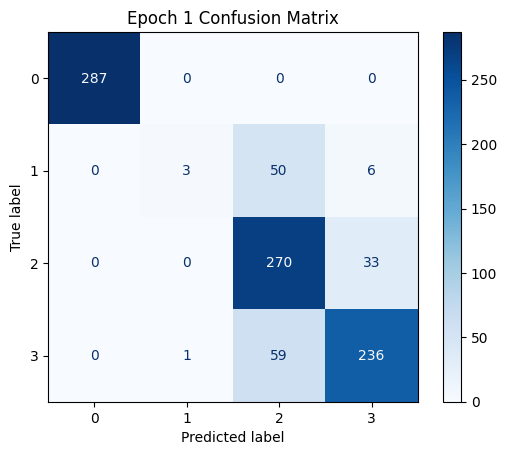


--- Epoch 2/70 ---
[Train] Batch 10/119 processed.
[Train] Batch 20/119 processed.
[Train] Batch 30/119 processed.
[Train] Batch 40/119 processed.
[Train] Batch 50/119 processed.
[Train] Batch 60/119 processed.
[Train] Batch 70/119 processed.
[Train] Batch 80/119 processed.
[Train] Batch 90/119 processed.
[Train] Batch 100/119 processed.
[Train] Batch 110/119 processed.
[Train] Batch 119/119 processed.
Training Loss: 0.681643, Training Accuracy: 67.62%
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 2 Summary:
  - Time elapsed: 55.67 sec
  - Train Loss: 0.681643, Train Acc: 67.62%
  - Val Loss: 0.333936, Val Acc: 86.67%
  - Loss Gap (Val-Train)/Train: -51.01%
  -> Validation loss improved; model saved!


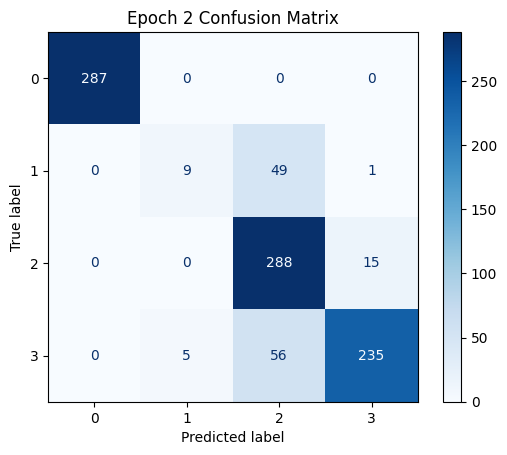


--- Epoch 3/70 ---
[Train] Batch 10/119 processed.
[Train] Batch 20/119 processed.
[Train] Batch 30/119 processed.
[Train] Batch 40/119 processed.
[Train] Batch 50/119 processed.
[Train] Batch 60/119 processed.
[Train] Batch 70/119 processed.
[Train] Batch 80/119 processed.
[Train] Batch 90/119 processed.
[Train] Batch 100/119 processed.
[Train] Batch 110/119 processed.
[Train] Batch 119/119 processed.
Training Loss: 0.632687, Training Accuracy: 70.34%
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 3 Summary:
  - Time elapsed: 55.23 sec
  - Train Loss: 0.632687, Train Acc: 70.34%
  - Val Loss: 0.308837, Val Acc: 87.51%
  - Loss Gap (Val-Train)/Train: -51.19%
  -> Validation loss improved; model saved!


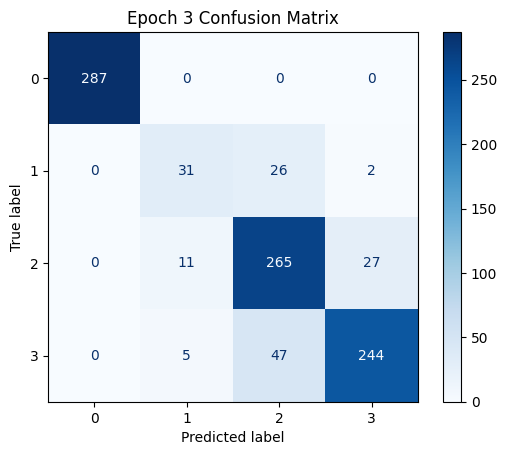


--- Epoch 4/70 ---
[Train] Batch 10/119 processed.
[Train] Batch 20/119 processed.
[Train] Batch 30/119 processed.
[Train] Batch 40/119 processed.
[Train] Batch 50/119 processed.
[Train] Batch 60/119 processed.
[Train] Batch 70/119 processed.
[Train] Batch 80/119 processed.
[Train] Batch 90/119 processed.
[Train] Batch 100/119 processed.
[Train] Batch 110/119 processed.
[Train] Batch 119/119 processed.
Training Loss: 0.613566, Training Accuracy: 71.27%
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 4 Summary:
  - Time elapsed: 55.57 sec
  - Train Loss: 0.613566, Train Acc: 71.27%
  - Val Loss: 0.344772, Val Acc: 85.93%
  - Loss Gap (Val-Train)/Train: -43.81%
  -> No improvement for 1 epoch(s).


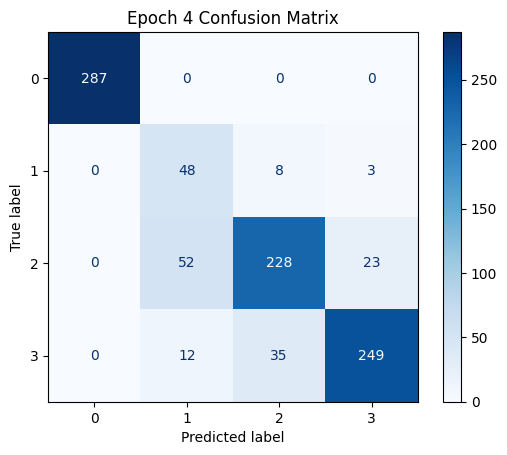


--- Epoch 5/70 ---
[Train] Batch 10/119 processed.
[Train] Batch 20/119 processed.
[Train] Batch 30/119 processed.
[Train] Batch 40/119 processed.
[Train] Batch 50/119 processed.
[Train] Batch 60/119 processed.
[Train] Batch 70/119 processed.
[Train] Batch 80/119 processed.
[Train] Batch 90/119 processed.
[Train] Batch 100/119 processed.
[Train] Batch 110/119 processed.
[Train] Batch 119/119 processed.
Training Loss: 0.612371, Training Accuracy: 72.46%
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 5 Summary:
  - Time elapsed: 55.19 sec
  - Train Loss: 0.612371, Train Acc: 72.46%
  - Val Loss: 0.302634, Val Acc: 88.36%
  - Loss Gap (Val-Train)/Train: -50.58%
  -> Validation loss improved; model saved!


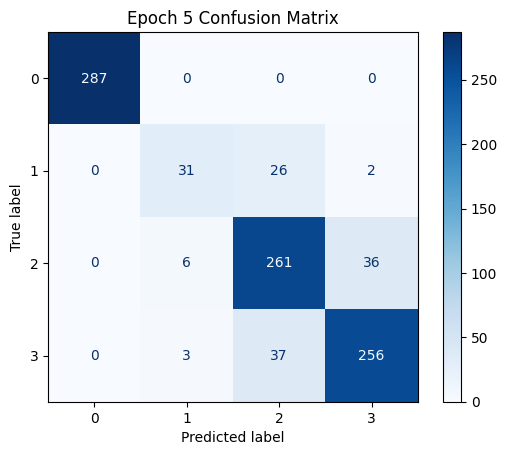


--- Epoch 6/70 ---
[Train] Batch 10/119 processed.
[Train] Batch 20/119 processed.
[Train] Batch 30/119 processed.
[Train] Batch 40/119 processed.
[Train] Batch 50/119 processed.
[Train] Batch 60/119 processed.
[Train] Batch 70/119 processed.
[Train] Batch 80/119 processed.
[Train] Batch 90/119 processed.
[Train] Batch 100/119 processed.
[Train] Batch 110/119 processed.
[Train] Batch 119/119 processed.
Training Loss: 0.633348, Training Accuracy: 70.42%
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 6 Summary:
  - Time elapsed: 55.04 sec
  - Train Loss: 0.633348, Train Acc: 70.42%
  - Val Loss: 0.261132, Val Acc: 89.84%
  - Loss Gap (Val-Train)/Train: -58.77%
  -> Validation loss improved; model saved!


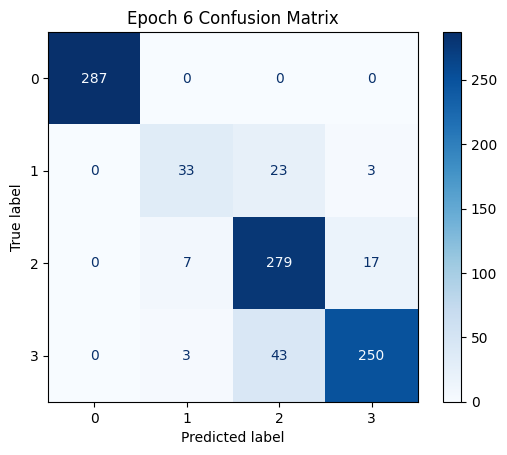


--- Epoch 7/70 ---
[Train] Batch 10/119 processed.
[Train] Batch 20/119 processed.
[Train] Batch 30/119 processed.
[Train] Batch 40/119 processed.
[Train] Batch 50/119 processed.
[Train] Batch 60/119 processed.
[Train] Batch 70/119 processed.
[Train] Batch 80/119 processed.
[Train] Batch 90/119 processed.
[Train] Batch 100/119 processed.
[Train] Batch 110/119 processed.
[Train] Batch 119/119 processed.
Training Loss: 0.576558, Training Accuracy: 71.69%
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 7 Summary:
  - Time elapsed: 55.02 sec
  - Train Loss: 0.576558, Train Acc: 71.69%
  - Val Loss: 0.293401, Val Acc: 88.15%
  - Loss Gap (Val-Train)/Train: -49.11%
  -> No improvement for 1 epoch(s).


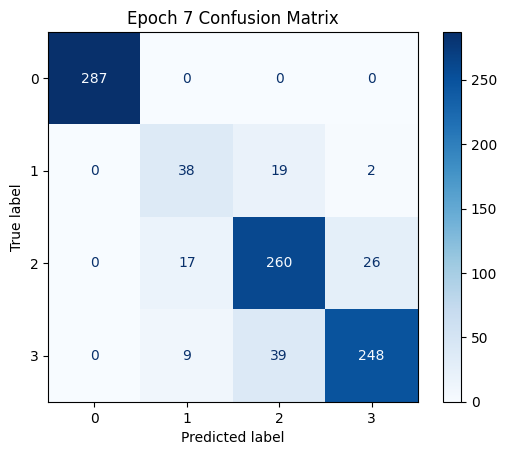


--- Epoch 8/70 ---
[Train] Batch 10/119 processed.
[Train] Batch 20/119 processed.
[Train] Batch 30/119 processed.
[Train] Batch 40/119 processed.
[Train] Batch 50/119 processed.
[Train] Batch 60/119 processed.
[Train] Batch 70/119 processed.
[Train] Batch 80/119 processed.
[Train] Batch 90/119 processed.
[Train] Batch 100/119 processed.
[Train] Batch 110/119 processed.
[Train] Batch 119/119 processed.
Training Loss: 0.584719, Training Accuracy: 72.51%
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 8 Summary:
  - Time elapsed: 54.63 sec
  - Train Loss: 0.584719, Train Acc: 72.51%
  - Val Loss: 0.282679, Val Acc: 90.26%
  - Loss Gap (Val-Train)/Train: -51.66%
  -> No improvement for 2 epoch(s).


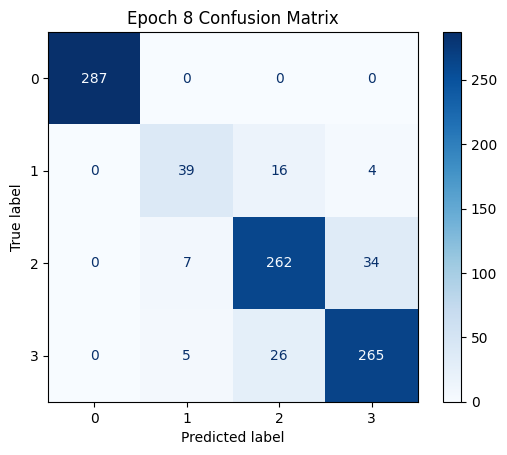


--- Epoch 9/70 ---
[Train] Batch 10/119 processed.
[Train] Batch 20/119 processed.
[Train] Batch 30/119 processed.
[Train] Batch 40/119 processed.
[Train] Batch 50/119 processed.
[Train] Batch 60/119 processed.
[Train] Batch 70/119 processed.
[Train] Batch 80/119 processed.
[Train] Batch 90/119 processed.
[Train] Batch 100/119 processed.
[Train] Batch 110/119 processed.
[Train] Batch 119/119 processed.
Training Loss: 0.582467, Training Accuracy: 71.64%
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 9 Summary:
  - Time elapsed: 55.18 sec
  - Train Loss: 0.582467, Train Acc: 71.64%
  - Val Loss: 0.326015, Val Acc: 87.20%
  - Loss Gap (Val-Train)/Train: -44.03%
  -> No improvement for 3 epoch(s).


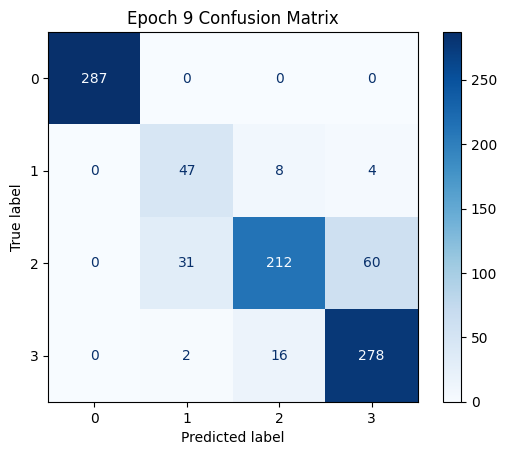


--- Epoch 10/70 ---
[Train] Batch 10/119 processed.
[Train] Batch 20/119 processed.
[Train] Batch 30/119 processed.
[Train] Batch 40/119 processed.
[Train] Batch 50/119 processed.
[Train] Batch 60/119 processed.
[Train] Batch 70/119 processed.
[Train] Batch 80/119 processed.
[Train] Batch 90/119 processed.
[Train] Batch 100/119 processed.
[Train] Batch 110/119 processed.
[Train] Batch 119/119 processed.
Training Loss: 0.554919, Training Accuracy: 73.52%
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 10 Summary:
  - Time elapsed: 54.96 sec
  - Train Loss: 0.554919, Train Acc: 73.52%
  - Val Loss: 0.273798, Val Acc: 88.36%
  - Loss Gap (Val-Train)/Train: -50.66%
  -> No improvement for 4 epoch(s).


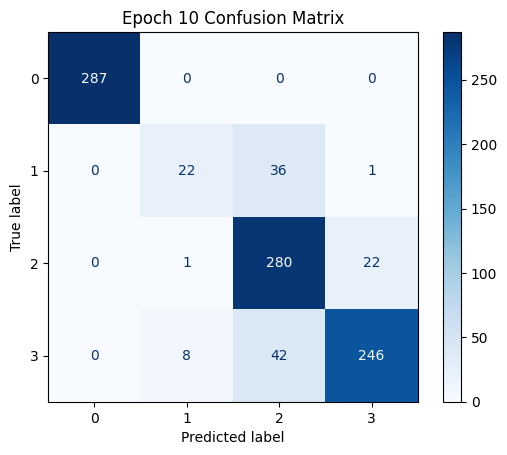


--- Epoch 11/70 ---
[Train] Batch 10/119 processed.
[Train] Batch 20/119 processed.
[Train] Batch 30/119 processed.
[Train] Batch 40/119 processed.
[Train] Batch 50/119 processed.
[Train] Batch 60/119 processed.
[Train] Batch 70/119 processed.
[Train] Batch 80/119 processed.
[Train] Batch 90/119 processed.
[Train] Batch 100/119 processed.
[Train] Batch 110/119 processed.
[Train] Batch 119/119 processed.
Training Loss: 0.539525, Training Accuracy: 73.78%
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 11 Summary:
  - Time elapsed: 54.98 sec
  - Train Loss: 0.539525, Train Acc: 73.78%
  - Val Loss: 0.255008, Val Acc: 90.26%
  - Loss Gap (Val-Train)/Train: -52.73%
  -> Validation loss improved; model saved!


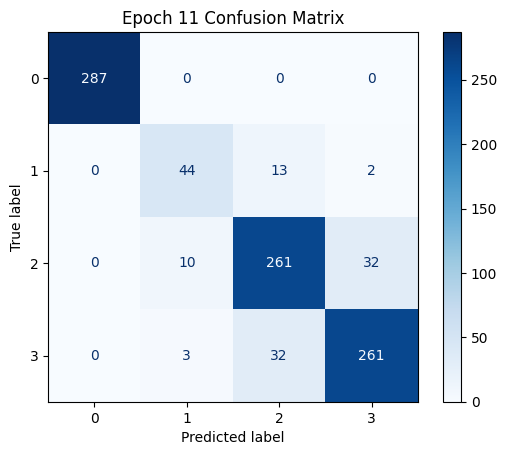


--- Epoch 12/70 ---
[Train] Batch 10/119 processed.
[Train] Batch 20/119 processed.
[Train] Batch 30/119 processed.
[Train] Batch 40/119 processed.
[Train] Batch 50/119 processed.
[Train] Batch 60/119 processed.
[Train] Batch 70/119 processed.
[Train] Batch 80/119 processed.
[Train] Batch 90/119 processed.
[Train] Batch 100/119 processed.
[Train] Batch 110/119 processed.
[Train] Batch 119/119 processed.
Training Loss: 0.531238, Training Accuracy: 73.86%
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 12 Summary:
  - Time elapsed: 54.45 sec
  - Train Loss: 0.531238, Train Acc: 73.86%
  - Val Loss: 0.242505, Val Acc: 90.69%
  - Loss Gap (Val-Train)/Train: -54.35%
  -> Validation loss improved; model saved!


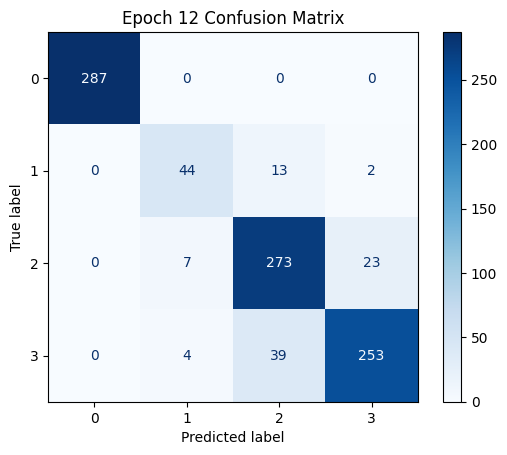


--- Epoch 13/70 ---
[Train] Batch 10/119 processed.
[Train] Batch 20/119 processed.
[Train] Batch 30/119 processed.
[Train] Batch 40/119 processed.
[Train] Batch 50/119 processed.
[Train] Batch 60/119 processed.
[Train] Batch 70/119 processed.
[Train] Batch 80/119 processed.
[Train] Batch 90/119 processed.
[Train] Batch 100/119 processed.
[Train] Batch 110/119 processed.
[Train] Batch 119/119 processed.
Training Loss: 0.530522, Training Accuracy: 74.55%
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 13 Summary:
  - Time elapsed: 54.85 sec
  - Train Loss: 0.530522, Train Acc: 74.55%
  - Val Loss: 0.242081, Val Acc: 90.58%
  - Loss Gap (Val-Train)/Train: -54.37%
  -> Validation loss improved; model saved!


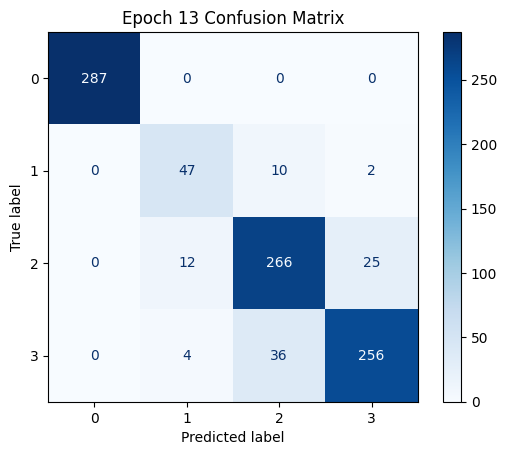


--- Epoch 14/70 ---
[Train] Batch 10/119 processed.
[Train] Batch 20/119 processed.
[Train] Batch 30/119 processed.
[Train] Batch 40/119 processed.
[Train] Batch 50/119 processed.
[Train] Batch 60/119 processed.
[Train] Batch 70/119 processed.
[Train] Batch 80/119 processed.
[Train] Batch 90/119 processed.
[Train] Batch 100/119 processed.
[Train] Batch 110/119 processed.
[Train] Batch 119/119 processed.
Training Loss: 0.543022, Training Accuracy: 73.60%
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 14 Summary:
  - Time elapsed: 54.96 sec
  - Train Loss: 0.543022, Train Acc: 73.60%
  - Val Loss: 0.237507, Val Acc: 91.64%
  - Loss Gap (Val-Train)/Train: -56.26%
  -> Validation loss improved; model saved!


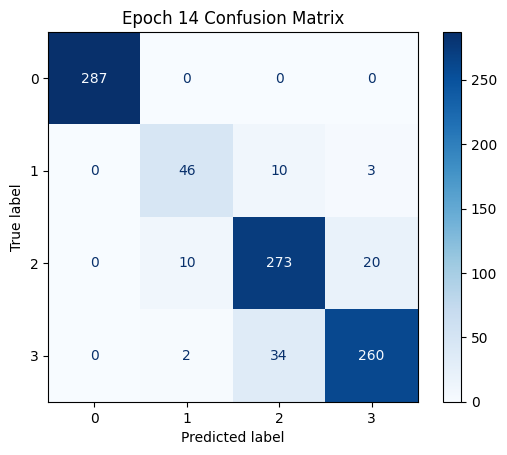


--- Epoch 15/70 ---
[Train] Batch 10/119 processed.
[Train] Batch 20/119 processed.
[Train] Batch 30/119 processed.
[Train] Batch 40/119 processed.
[Train] Batch 50/119 processed.
[Train] Batch 60/119 processed.
[Train] Batch 70/119 processed.
[Train] Batch 80/119 processed.
[Train] Batch 90/119 processed.
[Train] Batch 100/119 processed.
[Train] Batch 110/119 processed.
[Train] Batch 119/119 processed.
Training Loss: 0.525620, Training Accuracy: 74.02%
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 15 Summary:
  - Time elapsed: 55.32 sec
  - Train Loss: 0.525620, Train Acc: 74.02%
  - Val Loss: 0.231631, Val Acc: 91.43%
  - Loss Gap (Val-Train)/Train: -55.93%
  -> Validation loss improved; model saved!


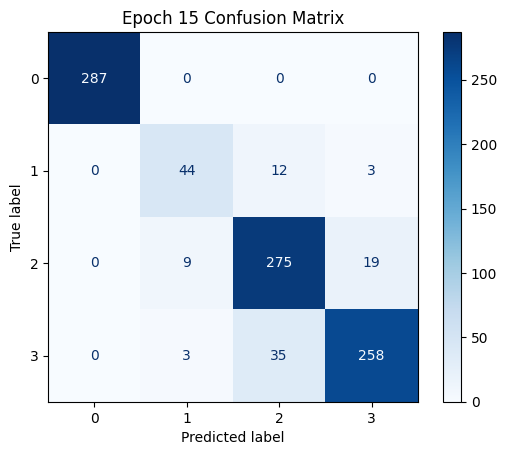


--- Epoch 16/70 ---
[Train] Batch 10/119 processed.
[Train] Batch 20/119 processed.
[Train] Batch 30/119 processed.
[Train] Batch 40/119 processed.
[Train] Batch 50/119 processed.
[Train] Batch 60/119 processed.
[Train] Batch 70/119 processed.
[Train] Batch 80/119 processed.
[Train] Batch 90/119 processed.
[Train] Batch 100/119 processed.
[Train] Batch 110/119 processed.
[Train] Batch 119/119 processed.
Training Loss: 0.522122, Training Accuracy: 74.23%
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 16 Summary:
  - Time elapsed: 55.07 sec
  - Train Loss: 0.522122, Train Acc: 74.23%
  - Val Loss: 0.231468, Val Acc: 90.58%
  - Loss Gap (Val-Train)/Train: -55.67%
  -> Validation loss improved; model saved!


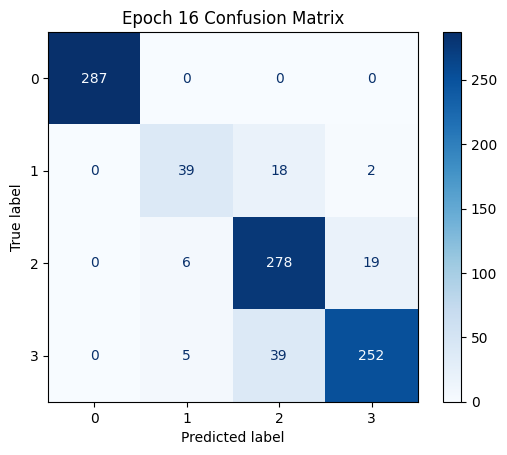


--- Epoch 17/70 ---
[Train] Batch 10/119 processed.
[Train] Batch 20/119 processed.
[Train] Batch 30/119 processed.
[Train] Batch 40/119 processed.
[Train] Batch 50/119 processed.
[Train] Batch 60/119 processed.
[Train] Batch 70/119 processed.
[Train] Batch 80/119 processed.
[Train] Batch 90/119 processed.
[Train] Batch 100/119 processed.
[Train] Batch 110/119 processed.
[Train] Batch 119/119 processed.
Training Loss: 0.513995, Training Accuracy: 73.73%
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 17 Summary:
  - Time elapsed: 54.91 sec
  - Train Loss: 0.513995, Train Acc: 73.73%
  - Val Loss: 0.228288, Val Acc: 90.58%
  - Loss Gap (Val-Train)/Train: -55.59%
  -> Validation loss improved; model saved!


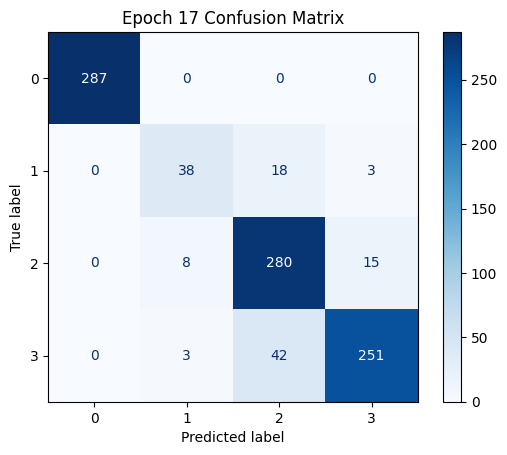


--- Epoch 18/70 ---
[Train] Batch 10/119 processed.
[Train] Batch 20/119 processed.
[Train] Batch 30/119 processed.
[Train] Batch 40/119 processed.
[Train] Batch 50/119 processed.
[Train] Batch 60/119 processed.
[Train] Batch 70/119 processed.
[Train] Batch 80/119 processed.
[Train] Batch 90/119 processed.
[Train] Batch 100/119 processed.
[Train] Batch 110/119 processed.
[Train] Batch 119/119 processed.
Training Loss: 0.509716, Training Accuracy: 74.18%
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 18 Summary:
  - Time elapsed: 55.11 sec
  - Train Loss: 0.509716, Train Acc: 74.18%
  - Val Loss: 0.230042, Val Acc: 91.64%
  - Loss Gap (Val-Train)/Train: -54.87%
  -> No improvement for 1 epoch(s).


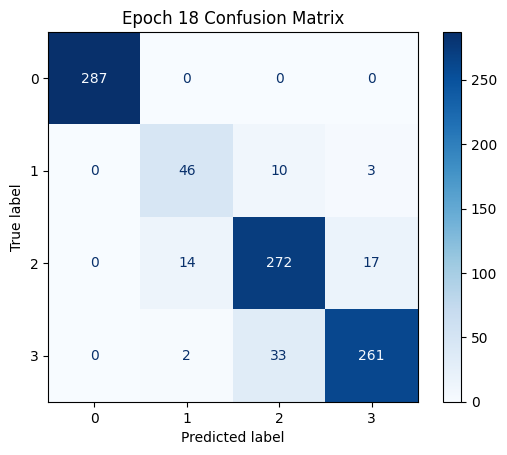


--- Epoch 19/70 ---
[Train] Batch 10/119 processed.
[Train] Batch 20/119 processed.
[Train] Batch 30/119 processed.
[Train] Batch 40/119 processed.
[Train] Batch 50/119 processed.
[Train] Batch 60/119 processed.
[Train] Batch 70/119 processed.
[Train] Batch 80/119 processed.
[Train] Batch 90/119 processed.
[Train] Batch 100/119 processed.
[Train] Batch 110/119 processed.
[Train] Batch 119/119 processed.
Training Loss: 0.507704, Training Accuracy: 74.55%
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 19 Summary:
  - Time elapsed: 54.77 sec
  - Train Loss: 0.507704, Train Acc: 74.55%
  - Val Loss: 0.228286, Val Acc: 91.11%
  - Loss Gap (Val-Train)/Train: -55.04%
  -> Validation loss improved; model saved!


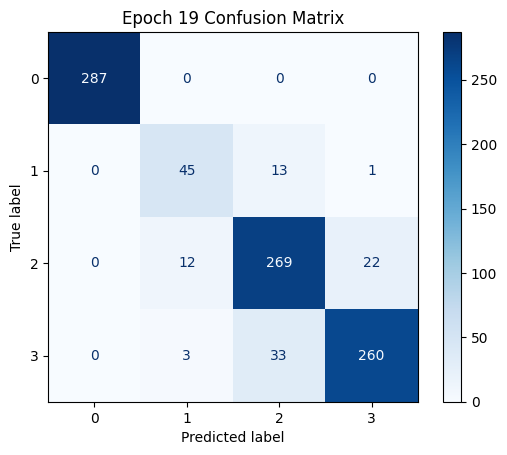


--- Epoch 20/70 ---
[Train] Batch 10/119 processed.
[Train] Batch 20/119 processed.
[Train] Batch 30/119 processed.
[Train] Batch 40/119 processed.
[Train] Batch 50/119 processed.
[Train] Batch 60/119 processed.
[Train] Batch 70/119 processed.
[Train] Batch 80/119 processed.
[Train] Batch 90/119 processed.
[Train] Batch 100/119 processed.
[Train] Batch 110/119 processed.
[Train] Batch 119/119 processed.
Training Loss: 0.510079, Training Accuracy: 73.49%
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 20 Summary:
  - Time elapsed: 55.11 sec
  - Train Loss: 0.510079, Train Acc: 73.49%
  - Val Loss: 0.229515, Val Acc: 91.11%
  - Loss Gap (Val-Train)/Train: -55.00%
  -> No improvement for 1 epoch(s).


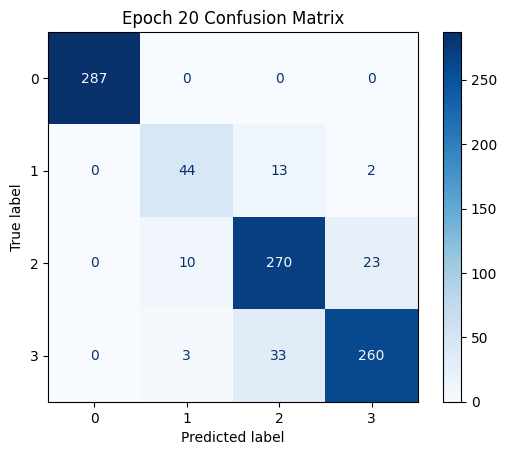


--- Epoch 21/70 ---
[Train] Batch 10/119 processed.
[Train] Batch 20/119 processed.
[Train] Batch 30/119 processed.
[Train] Batch 40/119 processed.
[Train] Batch 50/119 processed.
[Train] Batch 60/119 processed.
[Train] Batch 70/119 processed.
[Train] Batch 80/119 processed.
[Train] Batch 90/119 processed.
[Train] Batch 100/119 processed.
[Train] Batch 110/119 processed.
[Train] Batch 119/119 processed.
Training Loss: 0.528365, Training Accuracy: 73.12%
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 21 Summary:
  - Time elapsed: 54.87 sec
  - Train Loss: 0.528365, Train Acc: 73.12%
  - Val Loss: 0.228072, Val Acc: 91.32%
  - Loss Gap (Val-Train)/Train: -56.83%
  -> Validation loss improved; model saved!


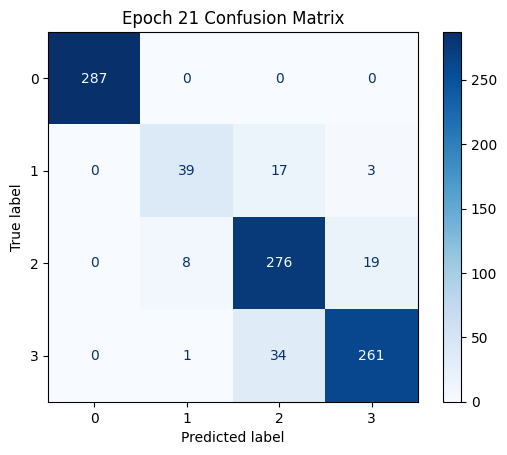


--- Epoch 22/70 ---
[Train] Batch 10/119 processed.
[Train] Batch 20/119 processed.
[Train] Batch 30/119 processed.
[Train] Batch 40/119 processed.
[Train] Batch 50/119 processed.
[Train] Batch 60/119 processed.
[Train] Batch 70/119 processed.
[Train] Batch 80/119 processed.
[Train] Batch 90/119 processed.
[Train] Batch 100/119 processed.
[Train] Batch 110/119 processed.
[Train] Batch 119/119 processed.
Training Loss: 0.490151, Training Accuracy: 75.63%
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 22 Summary:
  - Time elapsed: 55.23 sec
  - Train Loss: 0.490151, Train Acc: 75.63%
  - Val Loss: 0.233870, Val Acc: 90.69%
  - Loss Gap (Val-Train)/Train: -52.29%
  -> No improvement for 1 epoch(s).


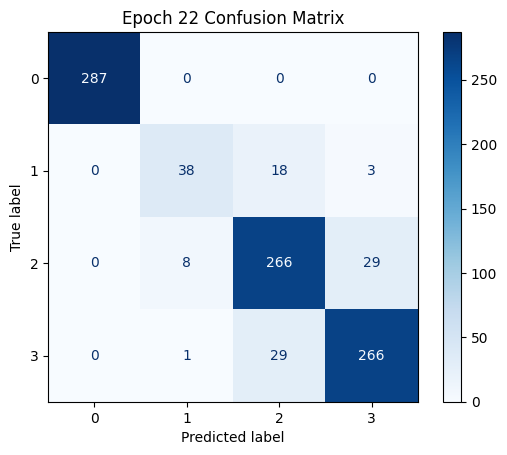


--- Epoch 23/70 ---
[Train] Batch 10/119 processed.
[Train] Batch 20/119 processed.
[Train] Batch 30/119 processed.
[Train] Batch 40/119 processed.
[Train] Batch 50/119 processed.
[Train] Batch 60/119 processed.
[Train] Batch 70/119 processed.
[Train] Batch 80/119 processed.
[Train] Batch 90/119 processed.
[Train] Batch 100/119 processed.
[Train] Batch 110/119 processed.
[Train] Batch 119/119 processed.
Training Loss: 0.492889, Training Accuracy: 74.44%
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 23 Summary:
  - Time elapsed: 54.90 sec
  - Train Loss: 0.492889, Train Acc: 74.44%
  - Val Loss: 0.223988, Val Acc: 91.32%
  - Loss Gap (Val-Train)/Train: -54.56%
  -> Validation loss improved; model saved!


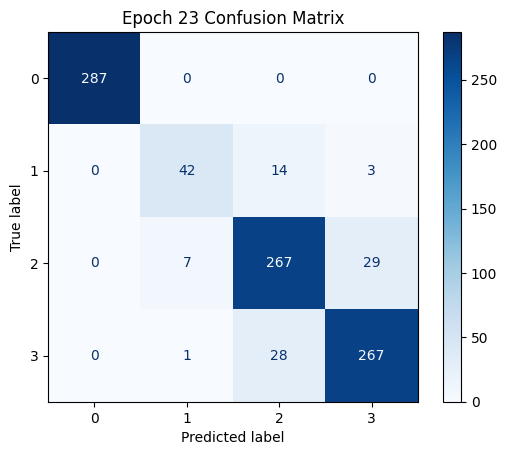


--- Epoch 24/70 ---
[Train] Batch 10/119 processed.
[Train] Batch 20/119 processed.
[Train] Batch 30/119 processed.
[Train] Batch 40/119 processed.
[Train] Batch 50/119 processed.
[Train] Batch 60/119 processed.
[Train] Batch 70/119 processed.
[Train] Batch 80/119 processed.
[Train] Batch 90/119 processed.
[Train] Batch 100/119 processed.
[Train] Batch 110/119 processed.
[Train] Batch 119/119 processed.
Training Loss: 0.502645, Training Accuracy: 75.13%
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 24 Summary:
  - Time elapsed: 55.30 sec
  - Train Loss: 0.502645, Train Acc: 75.13%
  - Val Loss: 0.239678, Val Acc: 90.48%
  - Loss Gap (Val-Train)/Train: -52.32%
  -> No improvement for 1 epoch(s).


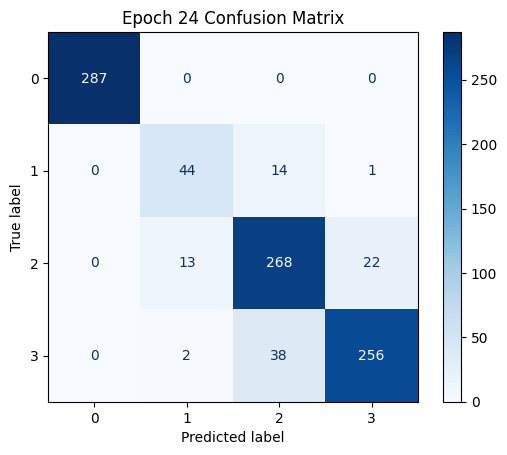


--- Epoch 25/70 ---
[Train] Batch 10/119 processed.
[Train] Batch 20/119 processed.
[Train] Batch 30/119 processed.
[Train] Batch 40/119 processed.
[Train] Batch 50/119 processed.
[Train] Batch 60/119 processed.
[Train] Batch 70/119 processed.
[Train] Batch 80/119 processed.
[Train] Batch 90/119 processed.
[Train] Batch 100/119 processed.
[Train] Batch 110/119 processed.
[Train] Batch 119/119 processed.
Training Loss: 0.489592, Training Accuracy: 76.22%
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 25 Summary:
  - Time elapsed: 54.91 sec
  - Train Loss: 0.489592, Train Acc: 76.22%
  - Val Loss: 0.234115, Val Acc: 90.79%
  - Loss Gap (Val-Train)/Train: -52.18%
  -> No improvement for 2 epoch(s).


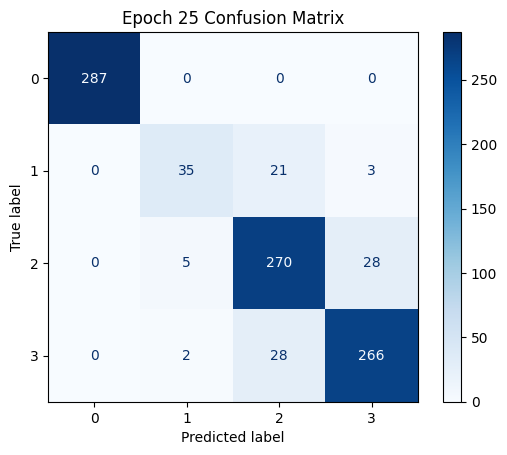


--- Epoch 26/70 ---
[Train] Batch 10/119 processed.
[Train] Batch 20/119 processed.
[Train] Batch 30/119 processed.
[Train] Batch 40/119 processed.
[Train] Batch 50/119 processed.
[Train] Batch 60/119 processed.
[Train] Batch 70/119 processed.
[Train] Batch 80/119 processed.
[Train] Batch 90/119 processed.
[Train] Batch 100/119 processed.
[Train] Batch 110/119 processed.
[Train] Batch 119/119 processed.
Training Loss: 0.492369, Training Accuracy: 75.37%
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 26 Summary:
  - Time elapsed: 54.69 sec
  - Train Loss: 0.492369, Train Acc: 75.37%
  - Val Loss: 0.229907, Val Acc: 91.22%
  - Loss Gap (Val-Train)/Train: -53.31%
  -> No improvement for 3 epoch(s).


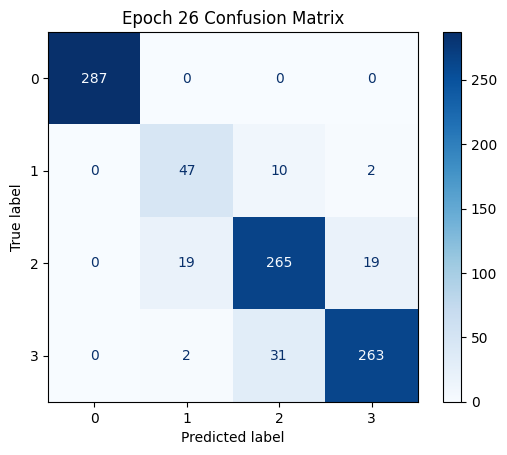


--- Epoch 27/70 ---
[Train] Batch 10/119 processed.
[Train] Batch 20/119 processed.
[Train] Batch 30/119 processed.
[Train] Batch 40/119 processed.
[Train] Batch 50/119 processed.
[Train] Batch 60/119 processed.
[Train] Batch 70/119 processed.
[Train] Batch 80/119 processed.
[Train] Batch 90/119 processed.
[Train] Batch 100/119 processed.
[Train] Batch 110/119 processed.
[Train] Batch 119/119 processed.
Training Loss: 0.490389, Training Accuracy: 74.97%
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 27 Summary:
  - Time elapsed: 55.03 sec
  - Train Loss: 0.490389, Train Acc: 74.97%
  - Val Loss: 0.231370, Val Acc: 91.22%
  - Loss Gap (Val-Train)/Train: -52.82%
  -> No improvement for 4 epoch(s).


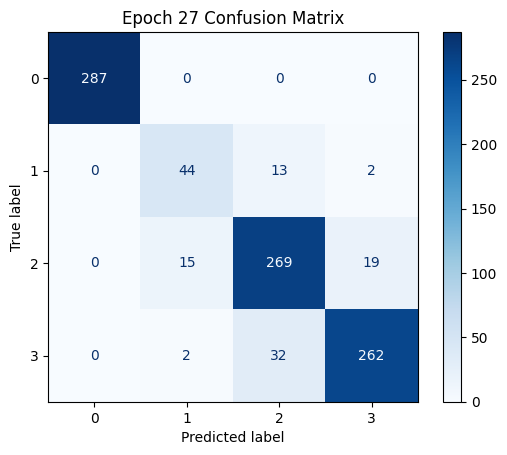


--- Epoch 28/70 ---
[Train] Batch 10/119 processed.
[Train] Batch 20/119 processed.
[Train] Batch 30/119 processed.
[Train] Batch 40/119 processed.
[Train] Batch 50/119 processed.
[Train] Batch 60/119 processed.
[Train] Batch 70/119 processed.
[Train] Batch 80/119 processed.
[Train] Batch 90/119 processed.
[Train] Batch 100/119 processed.
[Train] Batch 110/119 processed.
[Train] Batch 119/119 processed.
Training Loss: 0.485853, Training Accuracy: 74.92%
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 28 Summary:
  - Time elapsed: 55.01 sec
  - Train Loss: 0.485853, Train Acc: 74.92%
  - Val Loss: 0.229241, Val Acc: 91.01%
  - Loss Gap (Val-Train)/Train: -52.82%
  -> No improvement for 5 epoch(s).
  -> Early stopping triggered!

Total Training Time: 2811.61 seconds

Best model loaded for final evaluation.


In [ ]:

transfer_learning_model = TransferLearningResNet50(num_classes=len(CLASSES), dropout_rate=0.4)

trained_model, history = train_transfer_learning_model(
    transfer_learning_model,
    train_loader_original,
    test_loader_original,
    device,
    epochs=70,
    patience=5,
    lr=3e-4,
    save_path=SAVE_PATH
    )



Validation Loss: 0.2240
Validation Ordinal Accuracy: 91.32%
Validation Precision (weighted): 0.9129
Validation Recall (weighted): 0.9132
Validation F1 Score (weighted): 0.9127


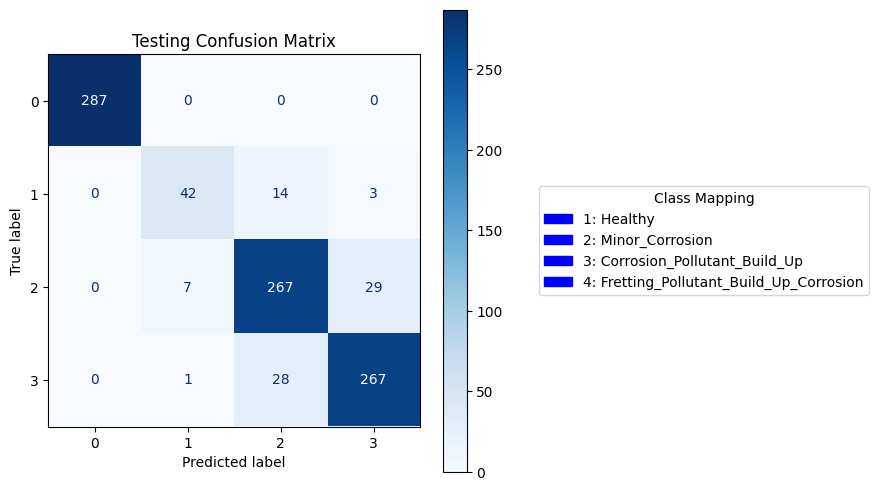

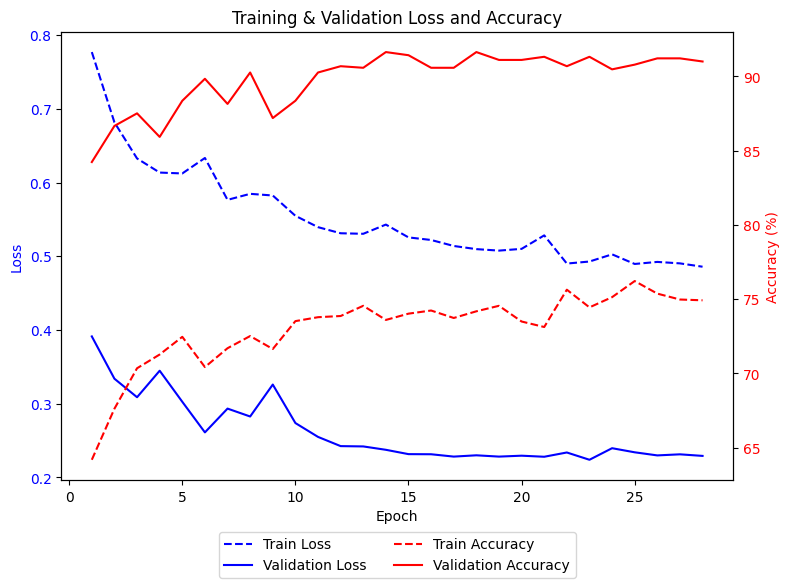

Total training compute time: 2811.61 seconds


In [ ]:
trained_model.eval()
total_val_samples = 0
running_val_loss = 0.0
criterion = nn.CrossEntropyLoss()
all_labels = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader_original:
        images, labels = images.to(device), labels.to(device)
        outputs = trained_model(images)
        loss = criterion(outputs, labels)
        running_val_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        total_val_samples += labels.size(0)
avg_loss = running_val_loss / total_val_samples

# Compute additional metrics using sklearn
val_accuracy = accuracy_score(all_labels, all_preds) * 100
precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
recall = recall_score(all_labels, all_preds, average='weighted')
f1 = f1_score(all_labels, all_preds, average='weighted')

# Print detailed validation metrics
mode = "Validation"
print(f'\n{mode} Loss: {avg_loss:.4f}')
print(f'{mode} Ordinal Accuracy: {val_accuracy:.2f}%')
print(f'{mode} Precision (weighted): {precision:.4f}')
print(f'{mode} Recall (weighted): {recall:.4f}')
print(f'{mode} F1 Score (weighted): {f1:.4f}')

# First, compute the confusion matrix
conf_matrix = confusion_matrix(all_labels, all_preds)

# Create the confusion matrix display
fig, ax = plt.subplots(figsize=(6, 6))  # Adjust figure size if needed
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap='Blues', ax=ax)

# Create legend patches
legend_patches = [mpatches.Patch(color='blue', label=f"{i+1}: {name}") for i, name in enumerate(CLASSES)]

# Place the legend outside the plot on the right
plt.legend(handles=legend_patches, title="Class Mapping", loc="center left", bbox_to_anchor=(1.3, 0.5))

# Set title
plt.title("Testing Confusion Matrix")
plt.show()

# --- Plot combined Training & Validation Loss and Accuracy curves ---
epochs_range = range(1, len(history['train_loss']) + 1)
fig, ax1 = plt.subplots(figsize=(8, 6))

# Plot Loss curves (primary y-axis)
line1, = ax1.plot(epochs_range, history['train_loss'], label='Train Loss', color='blue', linestyle='--')
line2, = ax1.plot(epochs_range, history['val_loss'], label='Validation Loss', color='blue')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create secondary y-axis for Accuracy
ax2 = ax1.twinx()
line3, = ax2.plot(epochs_range, history['train_acc'], label='Train Accuracy', color='red', linestyle='--')
line4, = ax2.plot(epochs_range, history['val_acc'], label='Validation Accuracy', color='red')
ax2.set_ylabel('Accuracy (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Combine legends from both axes
lines = [line1, line2, line3, line4]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)

plt.title("Training & Validation Loss and Accuracy")
plt.tight_layout()
plt.show()

# Optionally, print total training time metric
print(f"Total training compute time: {history['total_time']:.2f} seconds")


In [ ]:
!apt-get install -y pandoc texlive texlive-xetex texlive-latex-extra


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono fonts-texgyre
  fonts-urw-base35 libapache-pom-java libcmark-gfm-extensions0.29.0.gfm.3 libcmark-gfm0.29.0.gfm.3
  libcommons-logging-java libcommons-parent-java libfontbox-java libfontenc1 libgs9 libgs9-common
  libidn12 libijs-0.35 libjbig2dec0 libkpathsea6 libpdfbox-java libptexenc1 libruby3.0 libsynctex2
  libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13 lmodern pandoc-data poppler-data
  preview-latex-style rake ruby ruby-net-telnet ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0
  rubygems-integration t1utils teckit tex-common tex-gyre texlive-base texlive-binaries
  texlive-fonts-recommended texlive-latex-base texlive-latex-recommended texlive-pictures
  texlive-plain-generic tipa xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto fonts-fre

In [ ]:
%cd /content/drive/MyDrive/Colab Notebooks/MDR_Inspection/

/content/drive/.shortcut-targets-by-id/1CBsm-qkB1TuGqZoU-TjX6mM-QIJe2gcr/MDR_Inspection


In [ ]:
!jupyter nbconvert --to PDF "ResNet_Conductor_Classification.ipynb"

[NbConvertApp] Converting notebook ResNet_Conductor_Classification.ipynb to PDF
[NbConvertApp] Support files will be in ResNet_Conductor_Classification_files/
[NbConvertApp] Making directory ./ResNet_Conductor_Classification_files
[NbConvertApp] Writing 134075 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 708978 bytes to ResNet_Conductor_Classification.pdf
